# Final Model Walkthrough

This notebook now evaluates the actual final-model stack on the richer feature space.

Feature sources used here:
- metadata features from `src/baseline_model.py`
- turn-level aggregate features from `src/turn_features.py`

What it shows:
- the combined metadata + turn-feature candidate comparison
- grouped-human validation results for all implemented serious models
- the currently selected final model
- sample test predictions from the selected final model

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from src.baseline_model import build_folded_train_frame, load_test_frame
from src.model_candidates import (
    evaluate_candidates,
    fit_best_candidate_model,
    merge_optional_features,
    infer_feature_lists,
    get_candidate_builders,
    predict_test_frame,
    load_turn_feature_table,
)

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f"{x:,.4f}")

## 1. Load Metadata And Turn Features

In [2]:
train_frame = build_folded_train_frame(n_splits=5, seed=42)
test_frame = load_test_frame()
turn_feature_frame = load_turn_feature_table()

print('Train rows:', len(train_frame))
print('Test rows:', len(test_frame))
print('Turn feature rows:', len(turn_feature_frame))
print('Turn feature columns:', len(turn_feature_frame.columns))

turn_feature_frame.head()

Train rows: 50410
Test rows: 22363
Turn feature rows: 145546
Turn feature columns: 34


,game_id,human_nickname,turns_played,avg_turn_number,max_turn_number,play_turns,exchange_turns,pass_turns,challenge_turns,timeout_turns,end_turns,six_zero_rule_turns,missing_type_turns,scoring_turn_rate,zero_point_turn_rate,high_scoring_turn_rate,avg_points,median_points,max_points,std_points,avg_score_gain,max_score_gain,std_score_gain,avg_rack_len,avg_blank_tiles_on_rack,avg_move_len,max_move_len,bingo_like_turns,board_move_rate,final_score,points_per_turn,bingo_like_rate,non_play_turns,non_play_turn_rate
0,1,BetterBot,13,13.0000,25,13,0,0,0,0,0,0,0,1.0000,0.0000,0.1538,25.7692,24.0000,68,16.4578,25.7692,68,16.4578,6.7692,0.0000,4.0000,7,1,1.0000,335,25.7692,0.0769,0,0.0000
1,1,stevy,14,14.9286,27,13,0,0,0,0,1,0,0,1.0000,0.0000,0.3571,30.6429,25.0000,98,25.4909,30.6429,98,25.4909,6.0714,0.2143,3.5714,7,2,0.9286,429,30.6429,0.1429,0,0.0000
2,10,BetterBot,15,15.9333,29,14,0,0,0,0,1,0,0,1.0000,0.0000,0.4000,27.6667,24.0000,75,21.5859,27.6667,75,21.5859,6.1333,0.0667,3.8000,7,2,0.9333,415,27.6667,0.1333,0,0.0000
3,10,squashy,14,14.0000,27,12,0,2,0,0,0,0,0,0.8571,0.1429,0.2143,21.3571,16.5000,71,18.5415,21.3571,71,18.5415,7.0000,0.0714,3.3571,7,1,0.8571,299,21.3571,0.0714,2,0.1429
4,100,STEEBot,12,12.0000,23,12,0,0,0,0,0,0,0,1.0000,0.0000,0.6667,39.9167,37.5000,77,19.2423,39.9167,77,19.2423,7.0000,0.0833,4.5000,7,2,1.0000,479,39.9167,0.1667,0,0.0000


## 2. Candidate Comparison On The Combined Feature Set

In [3]:
candidate_summary = evaluate_candidates(
    train_frame,
    feature_frame=turn_feature_frame,
    key_columns=['game_id', 'human_nickname'],
)
candidate_summary

/home/leo/Desktop/PRML_proj/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/leo/Desktop/PRML_proj/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/leo/Desktop/PRML_proj/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/leo/Desktop/PRML_proj/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/leo/Desktop/PRML_proj/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,avg_rmse,avg_mae,std_rmse,std_mae,num_numeric_features,num_categorical_features
0,xgboost,150.3441,118.8258,17.0604,14.9266,43,7
1,ridge_onehot,150.7944,118.1805,13.2310,12.1981,43,7
2,hist_gbm,155.2655,122.1826,15.9469,13.2554,43,7
3,lightgbm,157.7103,124.0040,16.0415,12.7734,43,7


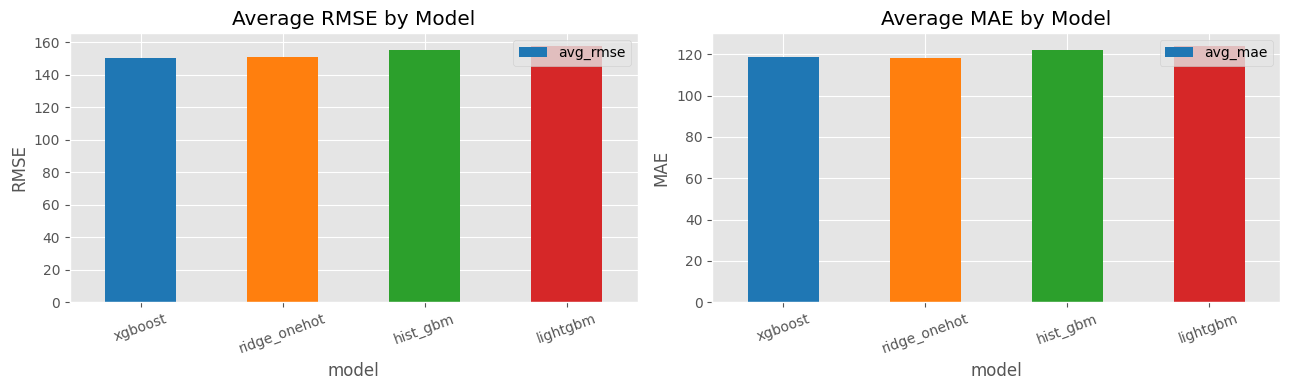

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

candidate_summary.plot.bar(x='model', y='avg_rmse', ax=axes[0], color=colors[:len(candidate_summary)])
axes[0].set_title('Average RMSE by Model')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=20)

candidate_summary.plot.bar(x='model', y='avg_mae', ax=axes[1], color=colors[:len(candidate_summary)])
axes[1].set_title('Average MAE by Model')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 3. Selected Final Model

In [5]:
selected_row = candidate_summary.iloc[0]
print('Selected final model:', selected_row['model'])
print('Average RMSE:', round(selected_row['avg_rmse'], 4))
print('Average MAE:', round(selected_row['avg_mae'], 4))

Selected final model: xgboost
Average RMSE: 150.3441
Average MAE: 118.8258


Interpretation:
- `xgboost` is now the best model by RMSE once turn-level features are included
- `ridge_onehot` remains very competitive and even has slightly better MAE
- this makes ridge a good control model and a possible blend partner later

## 4. Fold-Wise View

In [6]:
def evaluate_candidates_verbose(train_frame, turn_feature_frame):
    merged = merge_optional_features(
        train_frame,
        turn_feature_frame,
        key_columns=['game_id', 'human_nickname'],
    )
    numeric_features, categorical_features = infer_feature_lists(
        merged,
        target_column='human_rating',
        exclude_columns=['game_id', 'human_nickname'],
    )
    candidate_builders = get_candidate_builders()
    rows = []

    for model_name, builder in candidate_builders.items():
        for fold in sorted(merged['fold'].unique()):
            train_fold = merged[merged['fold'] != fold]
            valid_fold = merged[merged['fold'] == fold]

            X_train = train_fold[numeric_features + categorical_features]
            y_train = train_fold['human_rating']
            X_valid = valid_fold[numeric_features + categorical_features]
            y_valid = valid_fold['human_rating']

            model = builder(numeric_features, categorical_features)
            model.fit(X_train, y_train)
            preds = model.predict(X_valid)

            rows.append({
                'model': model_name,
                'fold': int(fold),
                'rmse': float(root_mean_squared_error(y_valid, preds)),
                'mae': float(mean_absolute_error(y_valid, preds)),
            })
    return pd.DataFrame(rows)

candidate_folds = evaluate_candidates_verbose(train_frame, turn_feature_frame)
candidate_folds

/home/leo/Desktop/PRML_proj/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/leo/Desktop/PRML_proj/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/leo/Desktop/PRML_proj/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/leo/Desktop/PRML_proj/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/leo/Desktop/PRML_proj/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,fold,rmse,mae
0,ridge_onehot,0,125.4747,95.3524
1,ridge_onehot,1,162.5391,130.2487
2,ridge_onehot,2,155.7853,117.2502
3,ridge_onehot,3,150.9315,122.0255
4,ridge_onehot,4,159.2412,126.0259
5,hist_gbm,0,134.3892,111.4820
6,hist_gbm,1,183.0891,146.3857
7,hist_gbm,2,148.4627,108.9767
8,hist_gbm,3,152.4315,120.6573
9,hist_gbm,4,157.9551,123.4112


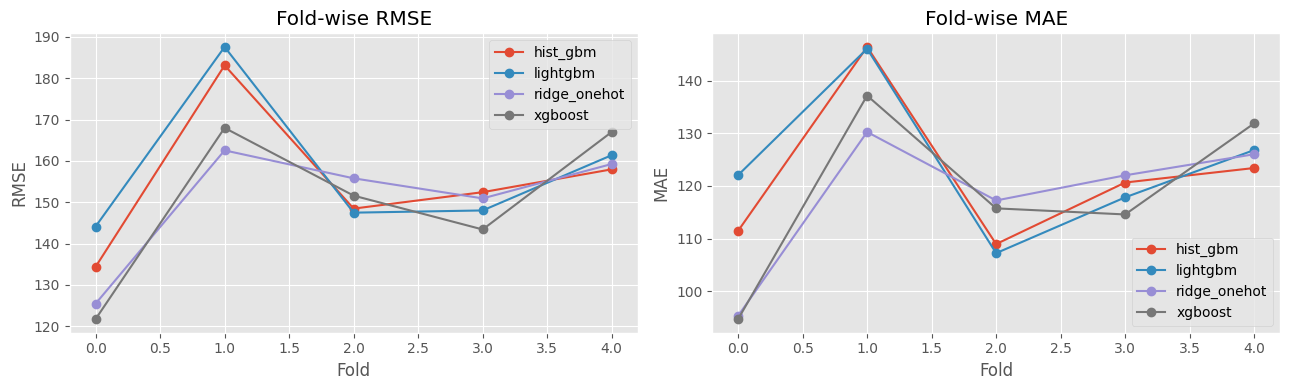

In [7]:
pivot_rmse = candidate_folds.pivot(index='fold', columns='model', values='rmse')
pivot_mae = candidate_folds.pivot(index='fold', columns='model', values='mae')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for model_name in pivot_rmse.columns:
    axes[0].plot(pivot_rmse.index, pivot_rmse[model_name], marker='o', label=model_name)
axes[0].set_title('Fold-wise RMSE')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('RMSE')
axes[0].legend()

for model_name in pivot_mae.columns:
    axes[1].plot(pivot_mae.index, pivot_mae[model_name], marker='o', label=model_name)
axes[1].set_title('Fold-wise MAE')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Fit The Selected Final Model On Full Training Data

In [8]:
selected_model_name, selected_model, numeric_features, categorical_features, refreshed_summary = fit_best_candidate_model(
    train_frame,
    feature_frame=turn_feature_frame,
    key_columns=['game_id', 'human_nickname'],
)

print('Selected model from scaffold:', selected_model_name)
print('Numeric features used:', len(numeric_features))
print('Categorical features used:', len(categorical_features))

/home/leo/Desktop/PRML_proj/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/leo/Desktop/PRML_proj/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/leo/Desktop/PRML_proj/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/leo/Desktop/PRML_proj/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/leo/Desktop/PRML_proj/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Selected model from scaffold: xgboost
Numeric features used: 43
Categorical features used: 7


In [9]:
test_predictions = predict_test_frame(
    selected_model,
    test_frame,
    numeric_features,
    categorical_features,
    feature_frame=turn_feature_frame,
    key_columns=['game_id', 'human_nickname'],
)

test_predictions.head(10)

,game_id,nickname,predicted_rating
0,2,Super,"1,994.9075"
1,7,Priya1,"1,973.0370"
2,11,TileRunner,"1,625.0188"
3,14,Anfield223,"1,992.1625"
4,27,friesbasil,"2,068.1472"
5,28,Eloquent,"1,769.1653"
6,32,Super,"2,034.1724"
7,40,eugenius,"1,751.4463"
8,41,marvin,"1,682.2821"
9,44,jlevedit,"1,652.0956"


## 6. Final Takeaways

What this notebook validates:
- the final-model pipeline now really uses `src/turn_features.py`
- the selected final model is no longer based on metadata alone
- the current selected model is `xgboost`
- the current grouped-human validation performance of the selected model is RMSE `150.3441`, MAE `118.8258`